This is the main file for Dennis Mitzeus' bachelor thesis project. The project includes data preprocessing, project structuring, technical implementation, and evaluation.

The current Architecture looks like this:

<img width="400px" src="./figures/artifact_flowchart_new.png"></img>

## Structure

This project will go through

1. Data Preprocessing
2. API setup
3. Technical Implementation
4. Evaluation

## Project

In [1]:
# Fixes need to restart kernel everytime I update components in separate files
%load_ext autoreload
%autoreload 2

%matplotlib inline

# Import Declarations
from IPython.display import Markdown, display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import seaborn as sns
import re
import requests
import tarfile
import os
import shutil
import csv
from dotenv import load_dotenv, dotenv_values
import os
import json
import spacy
import sqlite3

/Users/almandu/Documents/GitHub/bachelor-thesis-project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
TOTAL_SIZE = 100 # Total size of each flashcard set
BATCH_SIZE = 20 # How many words get introduced at a time eg. 20: ask LLM with 20 flashcards, then again with 40, then 60,..., until total size reached
MODEL_SAMPLE_SIZE = 10 # How many times to ask the same question (to get a distribution of probabilistic results)

### Data Preprocessing

#### Status for language Datasets Found:
* ✅ Swedish: Kelly (https://spraakbanken.gu.se/resurser/kelly)
* ✅ Spanish: ChatSubs (https://linkinghub.elsevier.com/retrieve/pii/S2352340923006650) (Data link: https://github.com/conversa-ai/ChatSubs)
* ✅ Korean: 한국어 학습용 어휘 목록(엑셀 파일) (TOPIK, from National Institute of Korean Language) (https://korean.go.kr/front/etcData/etcDataView.do?etc_seq=71)

#### Dataset explanations

##### Swedish

The Swedish dataset "Kelly" is used for Swedish. Swedish dataset contains 9 columns: "ID", "Raw freq", "WPM" "CEFR levels", "Source", "Grammar", "Swedish items for translation", "Word classes", and "Examples". 

Raw freq corresponds to the total frequency over the whole extracted corpus, WPM corresponds to a ratio of how many words per 1 000 000 words is this word, CEFR levels correspond to how advanced a word is following the Common European Framework of Reference for Languages, Source is from which corpus the word comes from, Grammar corresponds to certain prefixes or suffixes some word classes inherit (for example "att" before all root verbs), Swedish items for translation is the word itself, word classes correspond to which grammatical type a word is (more details under "Lookup" workspace in file datasets/1-raw/swedish.xls), lastly, examples provide example sentences of use for some words.

##### Spanish

The Spanish dataset "ChatSubs" is a collection of almost 20 000 000 dialogue subtitles from various kinds of movies and series. As this is not a preprocessed list of the most common words, it needs preprocessing.

By structuring all dialogues to be inputted directly into an NLP preprocessing library such as spaCy, a full database of lemmas, their PoS (grammar type) and frequency can be constructed. The frequency and PoS can then be used to determine which words in each grammar type qualify for the final flashcard set.

##### Korean

Korean dataset is from the National Korean Language Institute which is a put together list of the most common words in the Korean language for foreign learners practicing for the TOPIK (Test of Proficiency in Korean) test. Korean dataset contains 5 columns: "순위", "단어", "품사", "풀이", and "등급".

순위 corresponds to the frequency ranking based on a 2002 researcher report named "Survey on Modern Korean Usage Frequency", 단어 corresponds to the word itself, 품사 refers to the grammatical type a word is (more details can be found at [the official dataset site](https://korean.go.kr/front/etcData/etcDataView.do?etc_seq=71)),풀이 refers to the Hanja (漢字) versions of some words, and 등급 refers to which TOPIK level a word is in where A means basic B is intermediate and C is advanced level.

### Preprocessing based on some criteria

For our preprocessing we need to fulfill some critera to get a good subset of the datasets viable for testing in the thesis architecture. 

It requires:

1. Vocabulary list of 100 Words per Language
2. A varied set of grammar types (Nouns, Verbs etc.), some weight more than others such as verbs being more important than conjunctions for basic language.
3. The words should be the most common in most cases. This means relative frequency is better than raw frequency.

#### Batches

Batches are subsets of a final dataset for gradual introduction into the thesis architecture system and works similar to smaller independent datasets inside the bigger one, meaning each batch will have similar word type ratios and not purely based on commonality (in case of a vocabulary list of 100 words, most adjectives may be top 60 meaning no adjectives can ever be used until batches after top 60 gets introduced)

This is a visual image of batches: 

<img src="./figures/flashcard_batches.png" width="400px"></img>

### Preprocessing

In [3]:
from src.preprocessing.language.general import create_sorted_flashcard_set

In [4]:
# This is the final structure of each preprocessed final list
final_example_df = pd.DataFrame(
 columns=["word", "pos", "frequency"]
)

for i in range(TOTAL_SIZE):
    final_example_df = pd.concat([final_example_df, pd.DataFrame([{"word": "example word", "pos": "verb", "frequency": 1}])], ignore_index=True)

final_example_df

,word,pos,frequency
0,example word,verb,1
1,example word,verb,1
2,example word,verb,1
3,example word,verb,1
4,example word,verb,1
...,...,...,...
95,example word,verb,1
96,example word,verb,1
97,example word,verb,1
98,example word,verb,1


#### Swedish

In [11]:
from src.preprocessing.language.swedish import remove_and_merge_pos as swedish_remove_and_merge_pos

In [12]:
swedish_raw = pd.read_csv("data/2-extracted/swedish.csv", sep=";")  # import
swedish_raw.isnull().sum()

ID                                  0
Raw freq                         2650
WPM                                 0
CEFR levels                         0
Source                              0
Grammar                          2841
Swedish items for translation       0
Word classes                        0
Examples                         8180
dtype: int64

In [13]:
# changing WPM to numeric
swedish_raw["WPM"] = swedish_raw["WPM"].str.replace(",", ".").astype("Float64")

# drop rows with super high WPM values (outliers)
swedish_raw = swedish_raw[swedish_raw["WPM"] < 1000000]

In [14]:
swedish_clump_word_classes = {
    "noun": ["noun", "noun-en", "noun-ett", "noun-en/-ett"],
    "verb": ["verb", "aux verb"],
}

swedish_processed = swedish_remove_and_merge_pos(data=swedish_raw, clump_word_classes=swedish_clump_word_classes)

,word,pos,frequency
86,och,conj,26019.68
87,vara,verb,23017.26
88,i,prep,19272.89
89,ha,verb,15983.31
90,dess,pronoun,15935.58
...,...,...,...
238,värld,noun,617.89
242,folk,noun,606.98
243,regering,noun,603.37
248,utan,conj,586.71


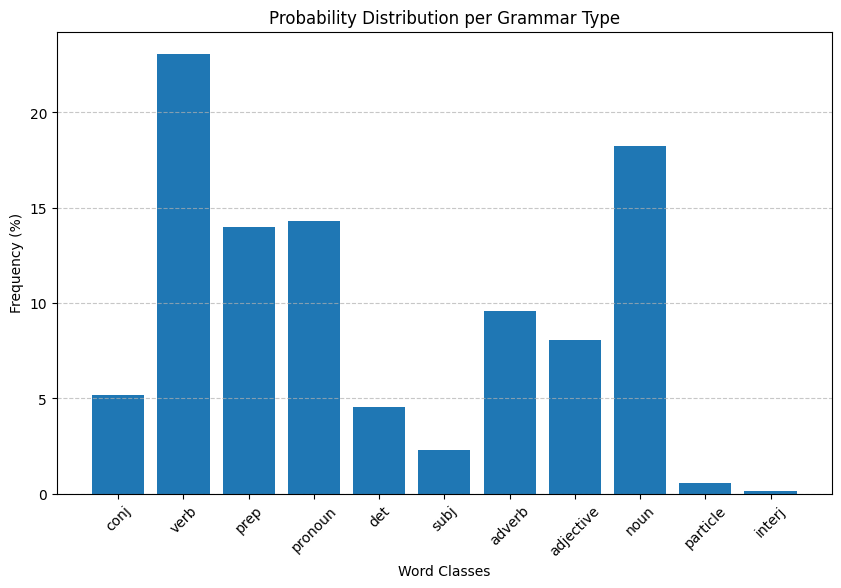

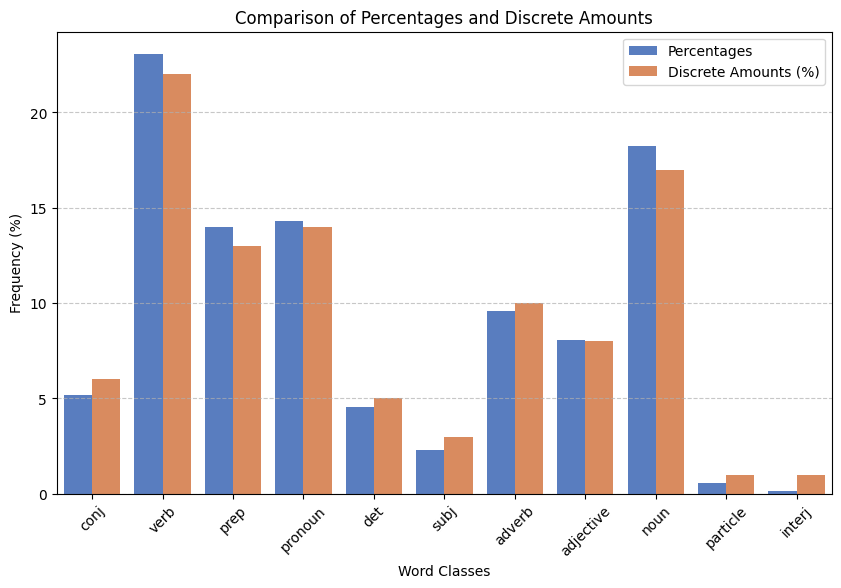

In [21]:
swedish_final, class_prior_fig, hamilton_fig = create_sorted_flashcard_set(
    data=swedish_processed,
    data_columns=["Swedish items for translation", "Word classes", "WPM"],
    pos_str="pos",
    frequency_str="frequency",
    rank_by="frequency",
    lang="swedish",
    target_columns=["word", "pos", "frequency"],
    drop_pos=["numeral", "proper name", "particip"],
    limit=TOTAL_SIZE,
)

display(swedish_final)
display(class_prior_fig[0])
display(hamilton_fig[0])

#### Spanish

In [7]:
from src.preprocessing.language.spanish import load_dataset as load_spanish_dataset
from src.preprocessing.language.spanish import (
    extract_data_from_dataset as spanish_extract_data_from_dataset,
)
from src.preprocessing.language.spanish import (
    grammar_preprocessing as spanish_grammar_preprocessing,
)
from src.preprocessing.language.spanish import (
    finalize_dataset as spanish_finalize_dataset,
)
from src.preprocessing.language.spanish import remove_artifact_entries as spanish_remove_artifact_entries

In [6]:
load_spanish_dataset() # downloads Spanish Dataset (ChatSubs) to /data/1-raw/spanish/

Download completed. Extracting files...
Extraction completed. Cleaning up...
Spanish dataset downloaded and extracted successfully.


In [7]:
spanish_extract_data_from_dataset(limit=20000, limit_sampling_seed=42) # extracts all dialogues from all documents into one .csv document
# spanish_extract_data_from_dataset(limit=1) # extracts all dialogues from all documents into one .csv document

(0.01%) Processing Document 1/20000 data/1-raw/spanish/0/3/4/1/1952621430.jsonl
(0.01%) Processing Document 2/20000 data/1-raw/spanish/2/8/8/0/1954600882.jsonl
(0.01%) Processing Document 3/20000 data/1-raw/spanish/5/4/3/4/1953384345.jsonl
(0.02%) Processing Document 4/20000 data/1-raw/spanish/9/1/3/7/1954437319.jsonl
(0.03%) Processing Document 5/20000 data/1-raw/spanish/4/1/8/5/1954615814.jsonl
(0.03%) Processing Document 6/20000 data/1-raw/spanish/4/2/6/9/1954779624.jsonl
(0.03%) Processing Document 7/20000 data/1-raw/spanish/3/0/7/3/1954683703.jsonl
(0.04%) Processing Document 8/20000 data/1-raw/spanish/2/0/5/2/1952192502.jsonl
(0.04%) Processing Document 9/20000 data/1-raw/spanish/9/8/1/1/1955121189.jsonl
(0.05%) Processing Document 10/20000 data/1-raw/spanish/2/4/3/3/1954753342.jsonl
(0.06%) Processing Document 11/20000 data/1-raw/spanish/0/7/5/6/1954766570.jsonl
(0.06%) Processing Document 12/20000 data/1-raw/spanish/9/1/2/9/1952129219.jsonl
(0.07%) Processing Document 13/20000 

In [8]:
spanish_df = spanish_grammar_preprocessing(
    nlp_size="small",
    cores_to_use=6,
    import_chunk_size=120000,
    processing_chunk_size=4000,
)  # Does preprocessing: tokenization, lemmatization, PoS tagging

print(spanish_df.sort_values(by="frequency", ascending=False).head(10))

Processing Batch 1/17
[2 minutes since start] Finished Batch 1 in 142.46 seconds (0.001187/item)
Processing Batch 2/17
[5 minutes since start] Finished Batch 2 in 161.83 seconds (0.001349/item)
Processing Batch 3/17
[8 minutes since start] Finished Batch 3 in 176.18 seconds (0.001468/item)
Processing Batch 4/17
[11 minutes since start] Finished Batch 4 in 184.92 seconds (0.001541/item)
Processing Batch 5/17
[15 minutes since start] Finished Batch 5 in 213.89 seconds (0.001782/item)
Processing Batch 6/17
[18 minutes since start] Finished Batch 6 in 222.74 seconds (0.001856/item)
Processing Batch 7/17
[22 minutes since start] Finished Batch 7 in 223.79 seconds (0.001865/item)
Processing Batch 8/17
[26 minutes since start] Finished Batch 8 in 238.71 seconds (0.001989/item)
Processing Batch 9/17
[30 minutes since start] Finished Batch 9 in 253.89 seconds (0.002116/item)
Processing Batch 10/17
[35 minutes since start] Finished Batch 10 in 283.58 seconds (0.002363/item)
Processing Batch 11/1

In [10]:
spanish_raw = spanish_finalize_dataset(limit=5000) # writes and gives top N entries
# spanish_raw = spanish_finalize_dataset(limit=TOTAL_SIZE) # writes and gives top N entries

spanish_raw

,lemma,pos,frequency,WPM
0,el,DET,2220619,64525.291469
1,de,ADP,1620894,47098.875489
2,él,PRON,1345010,39082.419037
3,ser,AUX,1252257,36387.263155
4,a,ADP,1115558,32415.153208
...,...,...,...,...
4995,â,NOUN,400,11.622938
4996,vas?\na,ADP,399,11.593880
4997,asesor,NOUN,399,11.593880
4998,martillo,NOUN,399,11.593880


In [11]:
spanish_processed = spanish_remove_artifact_entries(spanish_raw, word_column="lemma")

Removing artifact entries in data with 5000 rows.
Finished with a total of 4521 rows. (479 removed.)


,word,pos,frequency
0,el,DET,64525.291469
1,de,ADP,47098.875489
2,él,PRON,39082.419037
3,ser,AUX,36387.263155
4,a,ADP,32415.153208
...,...,...,...
227,contra,ADP,378.936831
284,saber,AUX,283.832142
539,debeer,AUX,146.565246
591,has,AUX,132.210918


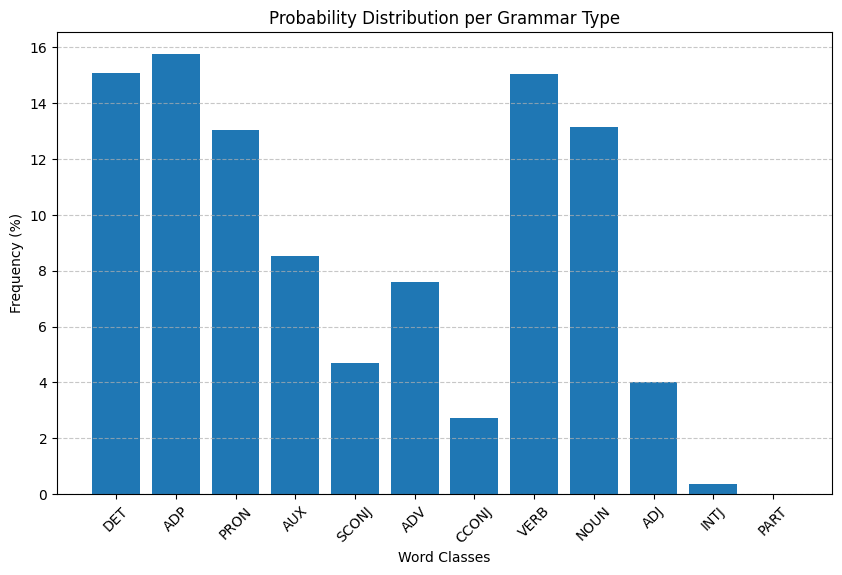

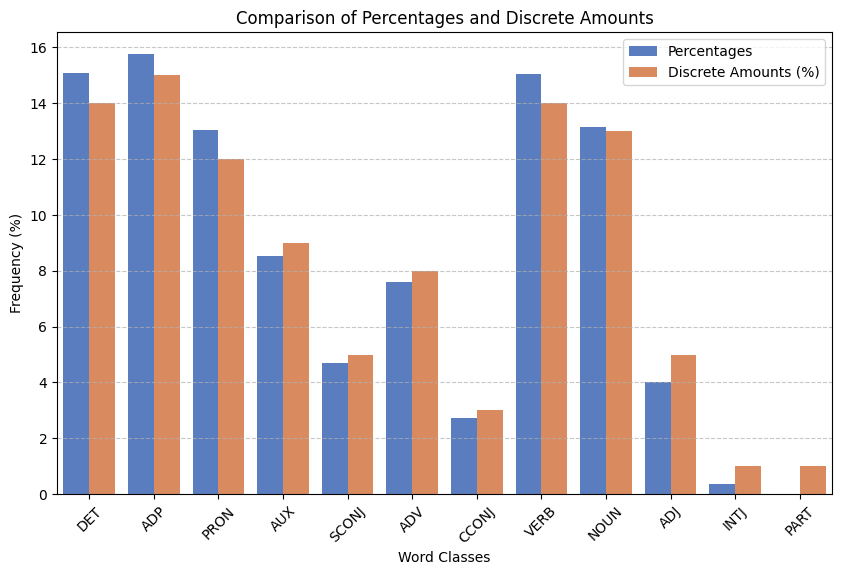

In [49]:
spanish_final, class_prior_fig, hamilton_fig = create_sorted_flashcard_set(
    data=spanish_processed, 
    data_columns=["lemma", "pos", "WPM"], 
    pos_str="pos",
    frequency_str="frequency",
    rank_by="frequency",
    lang="spanish",
    target_columns=["word", "pos", "frequency"], 
    drop_pos=["PROPN", "NUM", "PUNCT"],
    limit=TOTAL_SIZE)

display(spanish_final)
display(class_prior_fig[0])
display(hamilton_fig[0])

#### Korean

In [27]:
korean_raw = pd.read_csv("data/2-extracted/korean.csv", sep=";")  # import
korean_raw.isnull().sum()

순위      68
단어       0
품사       0
풀이    1956
등급       0
dtype: int64

In [31]:
korean_raw

,순위,단어,품사,풀이,등급
0,1195.0,가게,명,NaN,A
1,898.0,가격03,명,價格,B
2,2986.0,가구03,명,家口,C
3,7434.0,가구04,명,家具,B
4,4964.0,가까워지다,동,NaN,B
...,...,...,...,...,...
5960,489.0,힘들다,형,NaN,A
5961,10357.0,힘들어하다,동,NaN,C
5962,3305.0,힘쓰다,동,NaN,C
5963,9013.0,힘없이,부,NaN,C


In [29]:
korean_raw = korean_raw.dropna(subset=["순위"]) # drops words where there is no ranking

In [39]:
korean_raw["품사"].unique()

<ArrowStringArray>
['명', '동', '부', '형', '보', '의', '관', '불', '대', '수', '감']
Length: 11, dtype: str

In [43]:
# remove 단어 numbers
korean_raw["단어"] = korean_raw["단어"].str.replace(
    r"\d+$", "", regex=True
)

In [44]:
# replace korean names for display purposes
korean_raw["품사"] = korean_raw["품사"].replace(
    {
        "명": "noun",
        "동": "verb",
        "부": "adv",
        "형": "adj",
        "보": "aux",
        "의": "dep",
        "관": "det",
        "불": "neg",
        "대": "pron",
        "수": "num",
        "감": "intj",
    }
)

In [41]:
# As TOPIK dont have any frequency ranking, I'll weight the ranking instead
korean_raw["frequency_est"] = 1 / korean_raw["순위"]

,word,pos,frequency
262,것,dep,1.000000
5625,하다,verb,0.500000
4297,있다,aux,0.333333
4298,있다,adj,0.250000
1467,되다,verb,0.200000
...,...,...,...
67,가지,dep,0.007752
2218,번,dep,0.007246
2556,뿐,dep,0.005650
3298,아,intj,0.003367


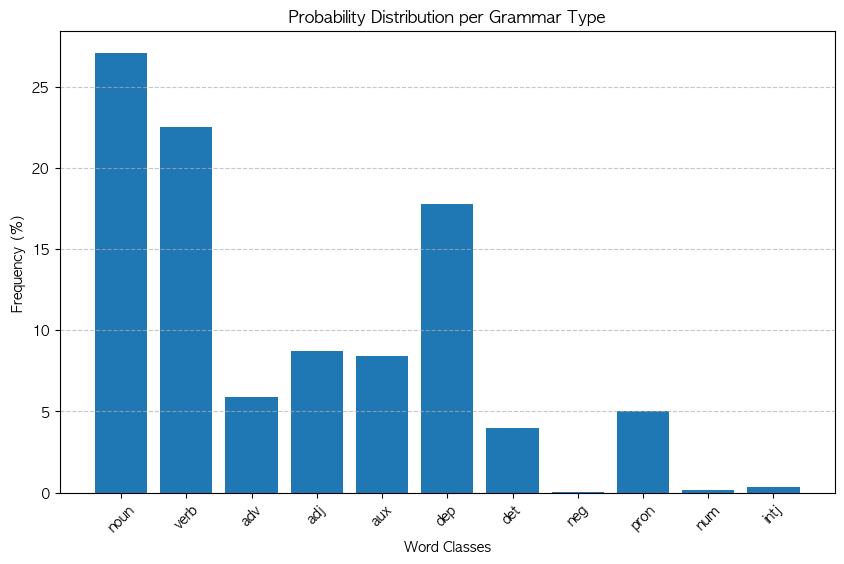

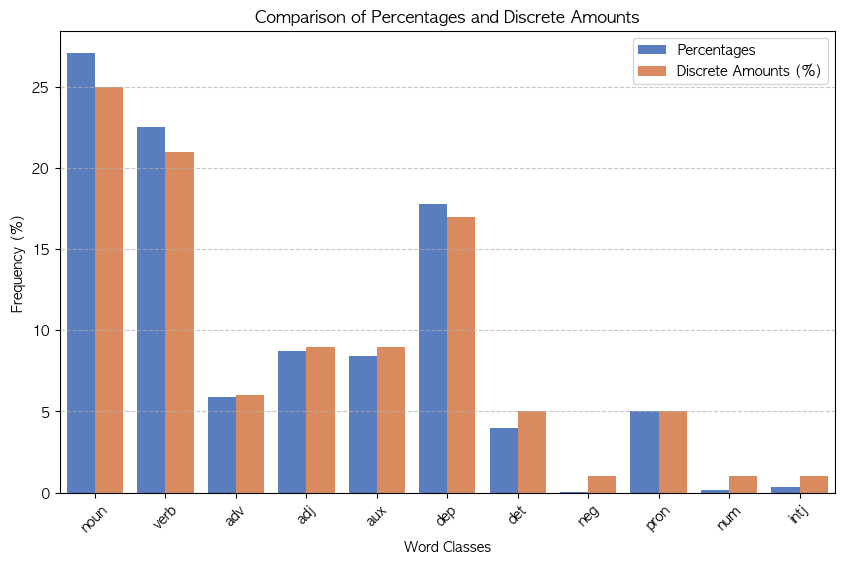

In [47]:
korean_final, class_prior_fig, hamilton_fig = create_sorted_flashcard_set(
    data=korean_raw,
    data_columns=["단어", "품사", "frequency_est"],
    pos_str="pos",
    frequency_str="frequency",
    rank_by="frequency",
    lang="korean",
    target_columns=["word", "pos", "frequency"],
    drop_pos=[],
    limit=TOTAL_SIZE,
)

display(korean_final)
display(class_prior_fig[0])
display(hamilton_fig[0])

### API Setup

In [49]:
# imports
from openai import OpenAI

from src.ai.models import Conversation_Model, Conversation
from src.ai.prompts import REVISED_PROMPT_STRING as SYSTEM_PROMPT_STRING

In [40]:
load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_KEY"))

### Technical Implementation NEW

In [43]:
swedish_vocab = pd.read_csv("data/3-final/swedish100.csv").sort_values(by="frequency", ascending=False)
spanish_vocab = pd.read_csv("data/3-final/spanish100.csv").sort_values(
    by="frequency", ascending=False
)
korean_vocab = pd.read_csv("data/3-final/korean100.csv").sort_values(
    by="frequency", ascending=False
)

In [44]:
test_questions_swedish = [  # Make some test questions
    "What's the difference between 'en' and 'ett' in swedish?",
    # "When do you use 'är' vs 'har' in swedish?",
    # "Why do you say 'jag heter' instead of 'jag är' in swedish?",
    # "What does 'lagom' mean in swedish?",
    # "How do I know if a word is a 'ett' or 'en' word in swedish?",
]

test_questions_spanish = []
test_questions_korean = []

In [46]:
print(
    f"""
Current Setup:
    Total Nr. Questions Swedish: {len(test_questions_swedish)}
    Total Nr. Questions Spanish: {len(test_questions_spanish)}
    Total Nr. Questions Korean: {len(test_questions_korean)}

    Flashcard Set Size:  {TOTAL_SIZE}
    Batch Size:          {BATCH_SIZE}
    Total Nr. Batches:   {TOTAL_SIZE // BATCH_SIZE}

    Total Nr. Samples (of generator model):   {MODEL_SAMPLE_SIZE}
"""
)


Current Setup:
    Total Nr. Questions Swedish: 1
    Total Nr. Questions Spanish: 0
    Total Nr. Questions Korean: 0

    Flashcard Set Size:  100
    Batch Size:          20
    Total Nr. Batches:   5

    Total Nr. Samples (of generator model):   10



In [47]:
conversation = ""
conversations_data = []

total_runs = (
    (TOTAL_SIZE // BATCH_SIZE) * len(test_questions_swedish) * MODEL_SAMPLE_SIZE
)

print(f"A total of {total_runs} conversations will be generated.")

run_counter = 0
for question_i, question in enumerate(test_questions_swedish):
    for batch_i in range(1):
    # for batch_i in range(TOTAL_SIZE // BATCH_SIZE):
        for sample_i in range(MODEL_SAMPLE_SIZE):
            run_counter += 1

            vocab_subset = swedish_vocab[: (batch_i + 1) * BATCH_SIZE]

            conversation = Conversation_Model(
                SYSTEM_PROMPT_STRING,
                model_client=client,
                model_name="gpt-5.2",
                keep_history=True,
                save_history_to_file=False,
                max_output_tokens=1,
            )

            # add flashcard limits
            conversation.import_word_library(vocab_subset)

            prompt = question
            response = conversation.ask(prompt)
            print(
                f"{run_counter}/{total_runs}: Sample {sample_i + 1} of question nr {question_i + 1} using {(batch_i + 1) * BATCH_SIZE} words Generated."
            )
            # print(f"You: {question}")
            # print(f"Model: {response}")
            # print("\n")

            conversations_data.append(
                Conversation(
                    id=f"{batch_i + 1}"
                    + f"{(batch_i + 1) * BATCH_SIZE}"
                    + f"{sample_i + 1}",
                    question_id=question_i,
                    sample_id=sample_i,
                    nr_vocab=(batch_i + 1) * BATCH_SIZE,
                    question=question,
                    response=response,
                    word_limits=conversation.flashcards,
                )
            )

            # as JSON
            with open(
                f"chats/test_questionings/question_{question_i + 1}_batchsize_{(batch_i + 1) * BATCH_SIZE}_sample_{sample_i + 1}.json",
                "w",
            ) as f:
                json_history = json.dumps(conversation.history, indent=4)
                f.write(json_history)

print("Done!")

### Technical Implementation

Technical implementation involves prompting, model design, flashcard imports, batch managements and running to gather data about the performance of measurable components of the system.

In this case testing to ask about different components of the swedish language and see how it performs.

In [41]:
# importing data
swedish_vocab = pd.read_csv("data/3-final/swedish100.csv")

# Preprocess into standard format for flashcards

# drop unnecessary columns & rename
swedish_vocab.drop(columns=["ID", "Raw freq", "Source", "Examples"], inplace=True)
swedish_vocab.rename(columns={
    "WPM": "freq",
    "Grammar": "affix",
    "CEFR levels": "level",
    "Swedish items for translation": "word",
    "Word classes": "grammar_type"
}, inplace=True)

swedish_vocab.head(100)

KeyError: "['ID', 'Raw freq', 'Source', 'Examples'] not found in axis"

In [ ]:
test_questions_swedish = [ # Make some test questions
    "What's the difference between 'en' and 'ett' in swedish?",
    # "When do you use 'är' vs 'har' in swedish?",
    # "Why do you say 'jag heter' instead of 'jag är' in swedish?",
    # "What does 'lagom' mean in swedish?",
    # "How do I know if a word is a 'ett' or 'en' word in swedish?",
]

conversation = ""

conversations_data = []

# test_questions_swedish = ["Hello"]

print(f"""
Current Setup:
    Total Nr. Questions: {len(test_questions_swedish)}

    Flashcard Set Size:  {TOTAL_SIZE}
    Batch Size:          {BATCH_SIZE}
    Total Nr. Batches:   {TOTAL_SIZE // BATCH_SIZE}

    Total Nr. Samples:   {MODEL_SAMPLE_SIZE}
""")

total_runs = (TOTAL_SIZE // BATCH_SIZE) * len(test_questions_swedish) * MODEL_SAMPLE_SIZE

print(f"A total of {total_runs} conversations will be generated.")

run_counter = 0
for question_i, question in enumerate(test_questions_swedish):
    # for batch_i in range(1):
    for batch_i in range(TOTAL_SIZE // BATCH_SIZE):
        for sample_i in range(MODEL_SAMPLE_SIZE):
            run_counter += 1

            vocab_subset = swedish_vocab[: (batch_i + 1) * BATCH_SIZE]

            conversation = Conversation_Model(
                SYSTEM_PROMPT_STRING,
                model_client=client,
                model_name="gpt-5.2",
                keep_history=True,
                save_history_to_file=False,
            )

            # add flashcard limits
            conversation.import_word_library(vocab_subset)

            prompt = question
            response = conversation.ask(prompt)
            print(
                f"{run_counter}/{total_runs}: Sample {sample_i + 1} of question nr {question_i + 1} using {(batch_i + 1) * BATCH_SIZE} words Generated."
            )
            # print(f"You: {question}")
            # print(f"Model: {response}")
            # print("\n")

            # save conversation for from testing questions

            # into conversation data
            # conversations_data.append(
            #     {
            #         "id": f"{batch_i + 1}" + f"{(batch_i + 1) * BATCH_SIZE}",
            #         "question_id": question_i + 1,
            #         "nr_vocab": (batch_i + 1) * BATCH_SIZE,
            #         "question": question,
            #         "response": response,
            #         "word_limits": conversation.flashcards
            #     }
            # )
            conversations_data.append(
                Conversation(
                    id=f"{batch_i + 1}" + f"{(batch_i + 1) * BATCH_SIZE}" + f"{sample_i + 1}",
                    question_id=question_i,
                    sample_id=sample_i,
                    nr_vocab=(batch_i + 1) * BATCH_SIZE,
                    question=question,
                    response=response,
                    word_limits=conversation.flashcards,
                )
            )

            # as JSON
            with open(
                f"chats/test_questionings/question_{question_i + 1}_batchsize_{(batch_i + 1) * BATCH_SIZE}_sample_{sample_i + 1}.json", "w"
            ) as f:
                json_history = json.dumps(conversation.history, indent=4)
                f.write(json_history)

print("Done!")

In [ ]:
# conversation.ask("This is good, but can you explain in english (so ignore the flashcard list for now) why you use so many new vocabulary when your limit is 10%? I am trying to understand how I can improve the system prompt so you better can limit yourself to the specified 10% MAXIMUM.")

In [ ]:
# display(Markdown(conversation.history[-1]["content"][0]["text"]))

## Beam Search Test

In [2]:
from src.ai.beam_search import BeamSearch

In [9]:
test_sequence = BeamSearch(3, ["the", "big", "small", "ugly", "cat", "fit"])

beams = test_sequence.update({"the": 0.2, "one": 0.1, "many": 0.15, "two": 0.001}) # Let's say this is the best first generated sequence

beams = test_sequence.update(
    [
        {"little1": 0.2, "wonk1": 0.0001, "reason1": 0.3, "world1": 0.002},
        {"little2": 0.2, "wonk2": 0.0001, "reason2": 0.3, "world2": 0.002},
        {"little3": 0.2, "wonk3": 0.0001, "reason3": 0.3, "world3": 0.002},
    ]
)

In [10]:
beams

['thereason1', 'manyreason2', 'thelittle1']

In [15]:
test_sequence = BeamSearch(3, ["the", "big", "small", "ugly", "cat", "fit"])


beams = test_sequence.update({"The": 0.3, "A": 0.25, "I": 0.2, "Xylophone": 0.001})
# Top 3 are "The", "A", "I"

print(beams)

beams = test_sequence.update(
    [
        {"cat": 0.4, "dog": 0.3, "unicorn": 0.001},  # for "The"
        {"man": 0.35, "woman": 0.3, "alien": 0.0001},  # for "A"
        {"robot": 0.3, "child": 0.25, "goblin": 0.0001},  # for "I"
    ]
)
print(beams)

beams = test_sequence.update(
    [
        {"sleeps": 0.4, "runs": 0.35, "flies": 0.0001},  # for "The cat"
        {"jumps": 0.4, "sings": 0.3, "dances": 0.0002},  # for "A man"
        {"eats": 0.35, "plays": 0.3, "throws": 0.0001},  # for "I robot"
    ]
)
print(beams)

beams = test_sequence.update(
    [
        {"quietly.": 0.5, "loudly.": 0.3, "magically.": 0.0001},  # "The cat sleeps"
        {"today.": 0.45, "yesterday.": 0.3, "tomorrow.": 0.0002},  # "A man jumps"
        {"games.": 0.4, "pizza.": 0.35, "monsters.": 0.0001},  # "I robot eats"
    ]
)

['The', 'A', 'I']
['The cat', 'The dog', 'A man']
['The cat sleeps', 'The cat runs', 'The dog jumps']


In [18]:
beams

['The cat sleeps quietly.', 'The cat runs today.', 'The cat sleeps loudly.']

In [36]:
test_sequence.visualize_tree("beam_tree_test")

# RESPONSE I GOT FROM GPT ABOUT IMPROVEMENTS
I used too much new vocabulary because your constraints are unusually strict in a way that’s hard for a general language model to satisfy reliably without extra guardrails. Concretely, several things happened:

The “known words” set is extremely small for explaining grammar To explain “en vs ett” naturally, I need words like “noun,” “gender,” “article,” “category,” “rule,” “example,” “most,” “some,” etc. Those weren’t in your flashcard list, so almost any normal explanation forces lots of “new” words.

I implicitly treated some words as “basic allowed” Your rules allow “the most basic phrases like Hello/Goodbye/How are you” and function words like articles. But they don’t clearly define an allowed list beyond that. Models often generalize “basic” to include common meta-words like “word,” “many,” “other,” “often,” “two,” “group,” etc. That’s why I produced vocabulary that felt “simple” but still violated your “only from flashcards” rule.

Ambiguity about what counts as a “word” Is “en-ord” one word or two? Is “a/an” one token? Do inflected forms count separately? Without a strict counting method, the model can’t reliably keep “≤10% new words.” Even if I try, I may be counting differently than you.

The “90% known words” rule conflicts with “explain” Your “Answer Structure” asks for explanation + examples. Explanations require meta-language. With a tiny whitelist, the model either:

becomes unhelpfully repetitive (“en… ett… den… det…”) or
breaks the whitelist to be helpful. I chose helpfulness, which violated the constraint.
I didn’t have a hard “stop” mechanism The prompt says “MAXIMUM 10%,” but it doesn’t force a deterministic behavior like: “If you can’t express it with allowed words, output: ‘I can’t answer with current vocabulary; please add X words.’” Without that, the model will keep generating.
How to improve your system prompt so it respects 10% MAXIMUM
Here are prompt changes that usually work:

A) Add a “hard refusal” clause
Tell the model what to do when it can’t comply:

If you cannot answer while keeping new words ≤10% AND using only flashcard words for known words, you MUST stop and ask the user to add specific missing words. Do not paraphrase using new words.

B) Define exactly what “new word” means
Specify counting rules, e.g.:

Count unique word types (not tokens), lowercased.
Hyphenated forms count as one word.
Proper nouns count as new unless in list.
Numbers, punctuation don’t count.
Conjugations are allowed as the same word (you already have this—good).
Or, if you want it simpler:

New words are any whitespace-separated tokens not in the flashcard list (after lowercasing and stripping punctuation).

C) Replace “90% known words” with a simpler absolute cap
Percentages are hard to control. Use a fixed cap:

Maximum of 3 new words per response. If more are needed, ask for permission or request more flashcards.

This is much easier for the model to follow than “10%.”

D) Provide an explicit “allowed meta-vocabulary” list
If you want explanations, give a small set of teaching words that are always allowed (and don’t count as new), e.g.:

word, noun, verb, adjective, article, gender, example, means, use, rule, group, common
This prevents the model from “inventing” random simple words while still letting it explain.

E) Add a self-check requirement
Instruct the model to do a final compliance check:

Before answering, verify every non-basic word is in the flashcard list. If not, replace it or stop.

F) Separate modes: “CI mode” vs “English explanation mode”
If you sometimes want English meta-explanations, make that a separate mode so the model doesn’t try to do both at once.

If you paste your current system prompt, I can propose a revised version that’s tighter (especially around counting and refusal behavior).

### Statistics Modeling

In statistics modeling it includes importing the created outputs and running the corrector to both get useful data for later evaluation, and prompting for iterative improvements

In [ ]:
from src.ai.models import Corrector
from src.ai.prompts import LLM_LEXICAL_SYSTEM_PROMPT

In [ ]:
corrector = Corrector() # Define corrector

# make flashcards into a list
list_of_flashcards = conversation.flashcards.split("\n")

# fake_history = [
#     {
#         "role": "user",
#         "content": [{"type": "output_text", "text": "Jag älskar pommes. Det måste finnas i mitt liv."}],
#     },
# ]

# corrector.fit(fake_history, list_of_flashcards)
corrector.fit(conversations_data, list_of_flashcards)

In [ ]:
display(Markdown(conversations_data[1].response))

In [ ]:
# Testing lexical constraints one time

## Lexical classification using separate LLM
llm_classified = corrector.lexical.llm_classification(client, "gpt-4o-mini", LLM_LEXICAL_SYSTEM_PROMPT)
# display(llm_classified.head(5)) # structure


llm_classification_ci_news = [[] for _ in range(MODEL_SAMPLE_SIZE)]
llm_classification_ci_olds = [[] for _ in range(MODEL_SAMPLE_SIZE)]

for obj in conversations_data:

    ci_old_ratio = 100 - round(obj.lexical.llm_classification["is_new"].to_numpy().sum()/len(obj.lexical.llm_classification["is_new"].tolist()) * 100)
    ci_new_ratio = round(
        obj.lexical.llm_classification["is_new"].to_numpy().sum()
        / len(obj.lexical.llm_classification["is_new"].tolist())
        * 100
    )

    print(f"Model CI ratio according to LLM (old/new): {ci_old_ratio}/{ci_new_ratio}")

    llm_classification_ci_news[obj.sample_id].append(ci_new_ratio)
    llm_classification_ci_olds[obj.sample_id].append(ci_old_ratio)


## Lexical classification using traditional NLP

In [ ]:
# test_corrector = Corrector()
# test_corrector.fit([
#     {
#         "role": "user",
#         "content": [{"type": "output_text", "text": "Jag älskar pommes. Det måste finnas i mitt liv."}],
#     },
# ], list_of_flashcards)


res = corrector.lexical.raw_checking()

raw_checking_ci_news = [[] for _ in range(MODEL_SAMPLE_SIZE)]
raw_checking_ci_olds = [[] for _ in range(MODEL_SAMPLE_SIZE)]

for obj in conversations_data:

    ci_old_ratio = 100 - round(obj.lexical.raw_checking["score"].to_numpy().sum()/len(obj.lexical.raw_checking["score"].tolist()) * 100)
    ci_new_ratio = round(
        obj.lexical.raw_checking["score"].to_numpy().sum()
        / len(obj.lexical.raw_checking["score"].tolist())
        * 100
    )

    print(f"Model CI ratio according to traditional NLP (old/new): {ci_old_ratio}/{ci_new_ratio}")

    raw_checking_ci_news[obj.sample_id].append(ci_new_ratio)
    raw_checking_ci_olds[obj.sample_id].append(ci_old_ratio)

In [ ]:
# Process CI ratios to put all samples together for calculating std etc
x = np.linspace(BATCH_SIZE, TOTAL_SIZE, TOTAL_SIZE // BATCH_SIZE)

y_llm_classification = np.array(llm_classification_ci_news)
llm_classification_means = np.mean(y_llm_classification, axis=0)
llm_classification_stds = np.std(y_llm_classification, axis=0)


y_raw_checking = np.array(raw_checking_ci_news)
raw_checking_means = np.mean(y_raw_checking, axis=0)
raw_checking_stds = np.std(y_raw_checking, axis=0)

In [ ]:
# Lineplot using

fig, axis = plt.subplots(1, 2, figsize=(20, 6))

axis[0].plot(
    x,
    llm_classification_means,
    label="(Mean) Words classified as NOT being from the Allowed Flashcards List",
    color="red",
)
axis[0].fill_between(
    x,
    llm_classification_means - llm_classification_stds,
    llm_classification_means + llm_classification_stds, alpha=0.3, label="Standard Deviation", color="orange")
axis[0].set_title(f"% of total tokens in output text classified BY AN LLM as being outside Allowed Flashcard List")

axis[1].plot(
    x,
    raw_checking_means,
    label="(Mean) Words classified as NOT being from the Allowed Flashcards List",
    color="red",
)
axis[1].fill_between(
    x,
    raw_checking_means - raw_checking_stds,
    raw_checking_means + raw_checking_stds,
    alpha=0.3,
    label="Standard Deviation",
    color="orange"
)
axis[1].set_title(
    f"% of total tokens in output text classified BY TRADITIONAL NLP as being outside Allowed Flashcard List"
)

for ax in axis:
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.set_ylim(0, 100)
    ax.axhline(y=10, linestyle="--", label="Maximum Allowed Threshold")
    ax.set_xlabel("Nr. Unique Allowed Flashcards")
    ax.set_ylabel("Classification (%)")
    ax.legend()

plt.show()

### Improvement Loop

Improvement loop loops between model and corrector to improve the final output to later measure the improvement and total performance in real-world tasks of this subsystem.

### Evaluation